<a href="https://colab.research.google.com/github/kylemwastaken/Data-wrangling/blob/main/Airplane_Cracshes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")

In [7]:
df.shape

(5268, 13)

In [8]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [9]:
df.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


Time- Keep as missing.
Location- use the modal location
Operator - use the mode
Flight #- keep as missing
Route - keep as missing
Type - use the mode
Registration- Keep as missing
cn/ln- keep as missing
aboard -  use the median
fatalities - use the mdeian
ground- use the median
summary -  keep as missing


In [11]:
fatality_locations= df[["Date","Location","Aboard","Fatalities"]].copy()
#fatality_locations.head()

In [12]:
fatality_locations["Fatalities"].idxmax()

2963

In [13]:
fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]

,2963
Date,03/27/1977
Location,"Tenerife, Canary Islands"
Aboard,644.0
Fatalities,583.0


In [14]:
fatality_locations[["Aboard","Fatalities"]]

,Aboard,Fatalities
0,2.0,1.0
1,5.0,5.0
2,1.0,1.0
3,20.0,14.0
4,30.0,30.0
...,...,...
5263,112.0,98.0
5264,4.0,4.0
5265,228.0,228.0
5266,1.0,1.0


In [16]:
fatality_locations[fatality_locations["Fatalities"]==0]
(fatality_locations["Fatalities"]==0).sum()

np.int64(58)

In [21]:
fatality_locations[["Region", "State/Country"]] = fatality_locations["Location"].str.split(",", n=1, expand=True)
fatality_locations[["Location", "Region", "State/Country"]].head(20)

,Location,Region,State/Country
0,"Fort Myer, Virginia",Fort Myer,Virginia
1,"AtlantiCity, New Jersey",AtlantiCity,New Jersey
2,"Victoria, British Columbia, Canada",Victoria,"British Columbia, Canada"
3,Over the North Sea,Over the North Sea,None
4,"Near Johannisthal, Germany",Near Johannisthal,Germany
5,"Tienen, Belgium",Tienen,Belgium
6,"Off Cuxhaven, Germany",Off Cuxhaven,Germany
7,"Near Jambol, Bulgeria",Near Jambol,Bulgeria
8,"Billericay, England",Billericay,England
9,"Potters Bar, England",Potters Bar,England


In [18]:
fatality_locations.sort_values(by="Fatalities" ,ascending=False).head(100)

,Date,Location,Aboard,Fatalities
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0
...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt


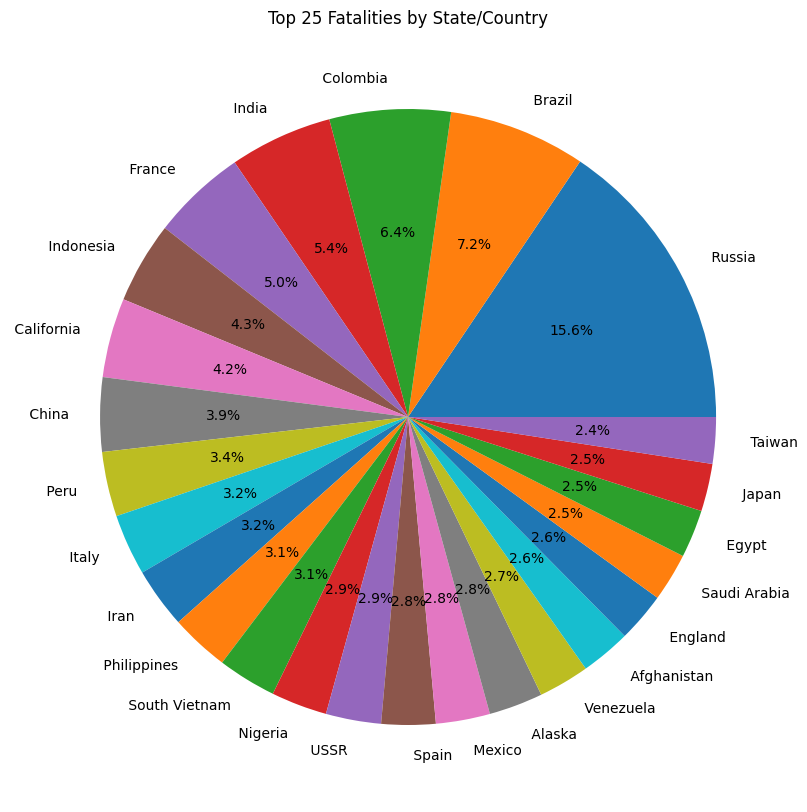

In [25]:
country_fatalities = (
    fatality_locations
    .groupby("State/Country")["Fatalities"]
    .sum()
    .sort_values(ascending=False)
)

top_25 = country_fatalities.head(25)

plt.figure(figsize=(10, 10))
plt.pie(
    top_25.values,
    labels=top_25.index,
    autopct="%1.1f%%"
)

plt.title("Top 25 Fatalities by State/Country")
plt.show()